# DSA 4060 – Recommender Systems
## Week 1 Practical: Popularity-Based Movie Recommender

**Name:** Abdiqalaq Issack  
**Student Number:** 671243  
**Date:** 21 September 2026  

### Purpose
The purpose of this practical is to explore the MovieLens dataset and build a simple non-personalized movie recommender system. The system will use movie ratings and rating counts to identify popular movies. I will also compare a minimum-rating approach with a weighted-rating approach to see how considering the number of ratings affects the recommendations.

## 1. Load and Inspect the Data

First, I will import the libraries needed to load, explore, and visualize the MovieLens dataset.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

### Define File Paths

The dataset files are stored in the `data` folder, while generated visualizations will be saved in the `images` folder.

In [2]:
PROJECT_ROOT = Path('..')

DATA_DIR = PROJECT_ROOT / 'data'
IMAGES_DIR = PROJECT_ROOT / 'images'

IMAGES_DIR.mkdir(exist_ok=True)

MOVIES_FILE = DATA_DIR / 'movies.csv'
RATINGS_FILE = DATA_DIR / 'ratings.csv'

### Load the Dataset

The MovieLens dataset contains information about movies and user ratings. I will load `movies.csv` and `ratings.csv` into Pandas DataFrames and check their dimensions.

In [3]:
movies = pd.read_csv(MOVIES_FILE)
ratings = pd.read_csv(RATINGS_FILE)

print('Movies shape:', movies.shape)
print('Ratings shape:', ratings.shape)

Movies shape: (9742, 3)
Ratings shape: (100836, 4)


### Preview and Inspect the Data

I will preview the first few rows of both datasets and inspect their columns, data types, and non-null values to understand the structure of the data.

In [4]:
display(movies.head())
display(ratings.head())

print(movies.info())
print(ratings.info())

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None


### Initial Data Inspection

- The `movies` dataset contains 9,742 rows and 3 columns: `movieId`, `title`, and `genres`. All three columns have 9,742 non-null values, which indicates that there are no missing values in these fields.

- The `ratings` dataset contains 100,836 rating records and 4 columns: `userId`, `movieId`, `rating`, and `timestamp`. All four columns contain 100,836 non-null values. The `rating` column is stored as a float, while the IDs and timestamp are stored as integers.

### Data Validation

Before building the recommender, I will check the datasets for missing values, duplicate records, the range of movie ratings, and any rating records that reference unknown movie IDs.

In [6]:
print('Missing values in movies:')
print(movies.isna().sum())

print('\nMissing values in ratings:')
print(ratings.isna().sum())

print('\nDuplicate movie rows:', movies.duplicated().sum())
print('Duplicate rating rows:', ratings.duplicated().sum())

print('Rating range:', ratings['rating'].min(), 'to', ratings['rating'].max())

print(
    'Unknown movie IDs:',
    (~ratings['movieId'].isin(movies['movieId'])).sum()
)

Missing values in movies:
movieId    0
title      0
genres     0
dtype: int64

Missing values in ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Duplicate movie rows: 0
Duplicate rating rows: 0
Rating range: 0.5 to 5.0
Unknown movie IDs: 0


### Validation Findings

- The validation checks show that both datasets are complete, with no missing values or duplicate rows. 
- The ratings range from 0.5 to 5.0, and all movie IDs in the ratings dataset have a matching movie in the movies dataset.
-  Therefore, no data cleaning or row removal is required before continuing with the analysis.

### Summary of User-Movie Interactions

Next, I will summarize the rating data by calculating the number of unique users, the number of movies that have received at least one rating, and the total number of rating interactions.

In [7]:
n_users = ratings['userId'].nunique()
n_movies_rated = ratings['movieId'].nunique()
n_interactions = len(ratings)

print('Unique users:', n_users)
print('Movies with at least one rating:', n_movies_rated)
print('Total rating interactions:', n_interactions)

print('\nRating statistics:')
print(ratings['rating'].describe())

Unique users: 610
Movies with at least one rating: 9724
Total rating interactions: 100836

Rating statistics:
count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64


### Interaction Summary Findings

- The ratings dataset contains 610 unique users and 100,836 user-movie rating interactions. Out of the 9,742 movies listed in the movies dataset, 9,724 have received at least one rating, meaning that 18 movies have no ratings in the ratings dataset.

- The average movie rating is approximately 3.50, with a median of 3.5. Ratings range from 0.5 to 5.0, while the middle 50% of ratings fall between 3.0 and 4.0.

## 2. Explore User-Item Interactions

### Ratings per User and per Movie

To understand how users interact with movies, I will calculate the number of ratings submitted by each user and the number of ratings received by each movie.

In [8]:
ratings_per_user = ratings.groupby('userId').size()
ratings_per_movie = ratings.groupby('movieId').size()

print('Ratings per user:')
print(ratings_per_user.describe())

print()

print('Ratings per movie:')
print(ratings_per_movie.describe())

Ratings per user:
count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
dtype: float64

Ratings per movie:
count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
dtype: float64


### Interaction Findings

- There is a large variation in how actively users rate movies. The average user has rated about 165 movies, while the median user has rated about 71 movies. The most active user has submitted 2,698 ratings, compared with a minimum of 20 ratings.

- Movie rating activity is much lower. A movie receives about 10 ratings on average, but the median is only 3 ratings. At least 25% of the rated movies have received only one rating, while the most-rated movie has 329 ratings. This shows that ratings are concentrated around a smaller group of movies, while many movies have very few ratings.

### Distribution of Movie Ratings

I will examine how frequently each rating value occurs in the dataset and visualize the distribution using a bar chart.

rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64


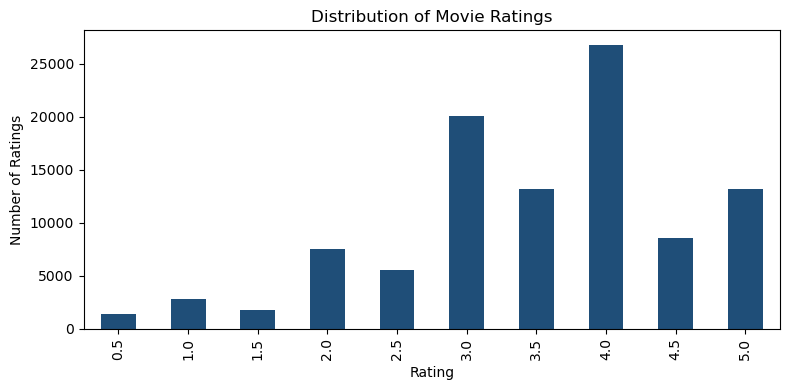

In [9]:
rating_distribution = ratings['rating'].value_counts().sort_index()

print(rating_distribution)

ax = rating_distribution.plot(
    kind='bar',
    color='#1F4E78',
    figsize=(8, 4)
)

ax.set_title('Distribution of Movie Ratings')
ax.set_xlabel('Rating')
ax.set_ylabel('Number of Ratings')

plt.tight_layout()
plt.show()

### Rating Distribution Findings

- The most common rating in the dataset is 4.0, with 26,818 ratings, followed by 3.0 with 20,047 ratings. Lower ratings occur less frequently, particularly 0.5, 1.0, and 1.5. Overall, the distribution shows that ratings between 3.0 and 5.0 occur more frequently than the lowest rating values.

### Interaction Matrix Sparsity

A complete user-item matrix would contain a rating for every possible combination of user and movie. Since users typically rate only a small number of available movies, I will calculate the proportion of possible interactions that are missing.

In [10]:
possible_interactions = n_users * n_movies_rated
observed_interactions = n_interactions

sparsity = 1 - (observed_interactions / possible_interactions)

print(f'Possible interactions: {possible_interactions:,}')
print(f'Observed interactions: {observed_interactions:,}')
print(f'Sparsity: {sparsity:.2%}')

Possible interactions: 5,931,640
Observed interactions: 100,836
Sparsity: 98.30%


### Sparsity Findings

- There are 5,931,640 possible user-movie interactions, but only 100,836 ratings are actually observed. This gives a sparsity of 98.30%, meaning that the vast majority of possible user-movie interactions have no rating.

- The high sparsity shows that each user has interacted with only a small portion of the available movies. This is an important challenge in recommender systems because there is limited information available about many user-item combinations.

## 3. Build a Popularity-Based Recommender

### Aggregate Ratings by Movie

To build the popularity recommender, I will calculate the average rating and total number of ratings received by each movie. These statistics will then be combined with the movie information so that each movie can be identified by its title and genre.

In [11]:
movie_stats = (
    ratings.groupby('movieId')
    .agg(
        average_rating=('rating', 'mean'),
        rating_count=('rating', 'count')
    )
    .reset_index()
)

movie_stats = movie_stats.merge(
    movies[['movieId', 'title', 'genres']],
    on='movieId',
    how='left',
    validate='one_to_one'
)

display(movie_stats.head())

,movieId,average_rating,rating_count,title,genres
0,1,3.920930,215,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,3.431818,110,Jumanji (1995),Adventure|Children|Fantasy
2,3,3.259615,52,Grumpier Old Men (1995),Comedy|Romance
3,4,2.357143,7,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,3.071429,49,Father of the Bride Part II (1995),Comedy


### Most Rated Movies

I will first rank movies according to the number of ratings they have received. This helps identify movies with the highest level of rating activity in the dataset.

In [12]:
most_rated = (
    movie_stats.sort_values(
        ['rating_count', 'average_rating'],
        ascending=[False, False]
    )
    .head(10)
)

display(most_rated[['title', 'rating_count', 'average_rating']])

,title,rating_count,average_rating
314,Forrest Gump (1994),329,4.164134
277,"Shawshank Redemption, The (1994)",317,4.429022
257,Pulp Fiction (1994),307,4.197068
510,"Silence of the Lambs, The (1991)",279,4.161290
1938,"Matrix, The (1999)",278,4.192446
224,Star Wars: Episode IV - A New Hope (1977),251,4.231076
418,Jurassic Park (1993),238,3.750000
97,Braveheart (1995),237,4.031646
507,Terminator 2: Judgment Day (1991),224,3.970982
461,Schindler's List (1993),220,4.225000


### Most Rated Movies Findings

- Forrest Gump (1994) is the most-rated movie in the dataset with 329 ratings and an average rating of approximately 4.16.
- The Shawshank Redemption (1994) is the second most-rated movie with 317 ratings, but it has a higher average rating of approximately 4.43.

- This shows that having the highest number of ratings does not necessarily mean that a movie has the highest average rating. 
- Rating count mainly reflects how widely a movie has been rated, so both rating volume and rating quality should be considered when producing recommendations.

### Highest Average-Rated Movies

Next, I will rank movies according to their average rating. I will also examine the number of ratings each movie received to determine whether average rating alone provides a reliable popularity measure.

In [13]:
highest_average = (
    movie_stats.sort_values(
        ['average_rating', 'rating_count'],
        ascending=[False, False]
    )
    .head(10)
)

display(
    highest_average[
        ['title', 'rating_count', 'average_rating']
    ]
)

,title,rating_count,average_rating
48,Lamerica (1994),2,5.0
87,Heidi Fleiss: Hollywood Madam (1995),2,5.0
869,Lesson Faust (1994),2,5.0
2593,Jonah Who Will Be 25 in the Year 2000 (Jonas q...,2,5.0
4384,Belle époque (1992),2,5.0
4583,Come and See (Idi i smotri) (1985),2,5.0
7347,Enter the Void (2009),2,5.0
121,"Awfully Big Adventure, An (1995)",1,5.0
405,Live Nude Girls (1995),1,5.0
432,In the Realm of the Senses (Ai no corrida) (1976),1,5.0


### Highest Average Rating Findings

- All of the Top 10 movies ranked by average rating have a perfect score of 5.0. However, these movies have received only one or two ratings each.
- This shows that average rating alone can be misleading because a movie can achieve a very high average based on a very small number of ratings.

- For example, a movie rated 5.0 by only one person would rank above a movie rated highly by hundreds of users. 
- Therefore, the number of ratings should also be considered when determining which movies are suitable for a popularity-based recommendation list.

### Minimum Ratings Baseline

To reduce the influence of movies with very few ratings, I will require a movie to have at least 50 ratings before it can appear in the recommendation list. The qualifying movies will then be ranked by their average rating.

In [14]:
MIN_RATINGS = 50

popular_movies = (
    movie_stats[movie_stats['rating_count'] >= MIN_RATINGS]
    .sort_values(
        ['average_rating', 'rating_count'],
        ascending=[False, False]
    )
    .head(10)
)

display(
    popular_movies[
        ['title', 'genres', 'rating_count', 'average_rating']
    ]
)

,title,genres,rating_count,average_rating
277,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
659,"Godfather, The (1972)",Crime|Drama,192,4.289062
2224,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936
974,Cool Hand Luke (1967),Drama,57,4.271930
602,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,97,4.268041
686,Rear Window (1954),Mystery|Thriller,84,4.261905
921,"Godfather: Part II, The (1974)",Crime|Drama,129,4.259690
6298,"Departed, The (2006)",Crime|Drama|Thriller,107,4.252336
913,Goodfellas (1990),Crime|Drama,126,4.250000
694,Casablanca (1942),Drama|Romance,100,4.240000


### Minimum Ratings Baseline Findings

- After requiring each movie to have at least 50 ratings, the recommendation list changes significantly.
- The Shawshank Redemption (1994) ranks first with 317 ratings and an average rating of approximately 4.43.

- Unlike the previous ranking based only on average rating, every movie in this list has received ratings from at least 50 users. 
- This reduces the influence of movies that have a perfect average score based on only one or two ratings and provides a more reliable popularity baseline.

### Popularity Recommender Function

I will now convert the popularity-ranking process into a reusable function. The function allows the minimum number of ratings and the number of recommendations returned to be changed when needed.

In [15]:
def recommend_popular_movies(stats, min_ratings=50, top_n=10):
    candidates = stats[stats['rating_count'] >= min_ratings].copy()

    return (
        candidates.sort_values(
            ['average_rating', 'rating_count'],
            ascending=[False, False]
        )
        .head(top_n)
        [['movieId', 'title', 'genres', 'rating_count', 'average_rating']]
    )


recommendations = recommend_popular_movies(
    movie_stats,
    min_ratings=50,
    top_n=10
)

display(recommendations)

,movieId,title,genres,rating_count,average_rating
277,318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
659,858,"Godfather, The (1972)",Crime|Drama,192,4.289062
2224,2959,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936
974,1276,Cool Hand Luke (1967),Drama,57,4.271930
602,750,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,97,4.268041
686,904,Rear Window (1954),Mystery|Thriller,84,4.261905
921,1221,"Godfather: Part II, The (1974)",Crime|Drama,129,4.259690
6298,48516,"Departed, The (2006)",Crime|Drama|Thriller,107,4.252336
913,1213,Goodfellas (1990),Crime|Drama,126,4.250000
694,912,Casablanca (1942),Drama|Romance,100,4.240000


## 4. Weighted Rating Recommender

### Select the Rating Threshold

- The minimum-rating method uses a fixed cutoff and excludes movies below that threshold. 
- As an alternative, I will use a weighted-rating approach that considers both the average rating of a movie and the amount of rating evidence available.

- The overall mean rating will be represented by `C`, while `m` will be based on the 90th percentile of movie rating counts.

In [16]:
C = ratings['rating'].mean()
m = movie_stats['rating_count'].quantile(0.90)

print(f'Overall mean rating C: {C:.3f}')
print(f'90th percentile rating count m: {m:.1f}')

Overall mean rating C: 3.502
90th percentile rating count m: 27.0


### Calculate Weighted Scores

- The overall mean rating is approximately 3.502, while the 90th percentile of movie rating counts is 27. 
- Therefore, movies with at least 27 ratings will qualify for the weighted-rating recommender.

- The weighted-rating formula balances a movie's average rating with the overall mean rating. Movies with more rating evidence are influenced more strongly by their own average rating.

In [17]:
qualified = movie_stats[
    movie_stats['rating_count'] >= m
].copy()

v = qualified['rating_count']
R = qualified['average_rating']

qualified['weighted_score'] = (
    (v / (v + m)) * R +
    (m / (v + m)) * C
)

weighted_recommendations = (
    qualified.sort_values(
        ['weighted_score', 'rating_count'],
        ascending=[False, False]
    )
    .head(10)
)

display(
    weighted_recommendations[
        [
            'title',
            'genres',
            'rating_count',
            'average_rating',
            'weighted_score'
        ]
    ]
)

,title,genres,rating_count,average_rating,weighted_score
277,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022,4.356227
659,"Godfather, The (1972)",Crime|Drama,192,4.289062,4.191973
2224,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936,4.187927
224,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,251,4.231076,4.160223
46,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,204,4.237745,4.151697
461,Schindler's List (1993),Drama|War,220,4.225000,4.145919
257,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,307,4.197068,4.140844
897,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi,211,4.215640,4.134630
1938,"Matrix, The (1999)",Action|Sci-Fi|Thriller,278,4.192446,4.131285
921,"Godfather: Part II, The (1974)",Crime|Drama,129,4.259690,4.128475


### Weighted Rating Findings

- The Shawshank Redemption (1994) ranks first under the weighted-rating method with a weighted score of approximately 4.356.
-  It has an average rating of 4.429 based on 317 ratings.

- The weighted method produces a different ranking from the minimum-50-ratings method because it considers both average rating and the amount of rating evidence. 
- Movies with many ratings, such as Star Wars: Episode IV - A New Hope, Pulp Fiction, and The Matrix, move into the Top 10 because their high average ratings are supported by a large number of ratings.

- The weighted scores are slightly lower than the raw average ratings because the formula adjusts each movie's rating toward the overall dataset mean of approximately 3.502. 
- This reduces the influence of high ratings that are based on less evidence.

### Comparison of the Two Recommendation Methods

- The minimum-rating and weighted-rating approaches will now be compared to determine how considering rating volume changes the recommended movies.

In [18]:
comparison = popular_movies[
    ['title', 'rating_count', 'average_rating']
].copy()

comparison['method'] = 'Minimum 50 ratings'

weighted_view = weighted_recommendations[
    ['title', 'rating_count', 'average_rating']
].copy()

weighted_view['method'] = 'Weighted score'

comparison_table = pd.concat(
    [comparison, weighted_view],
    ignore_index=True
)

display(comparison_table)

,title,rating_count,average_rating,method
0,"Shawshank Redemption, The (1994)",317,4.429022,Minimum 50 ratings
1,"Godfather, The (1972)",192,4.289062,Minimum 50 ratings
2,Fight Club (1999),218,4.272936,Minimum 50 ratings
3,Cool Hand Luke (1967),57,4.271930,Minimum 50 ratings
4,Dr. Strangelove or: How I Learned to Stop Worr...,97,4.268041,Minimum 50 ratings
5,Rear Window (1954),84,4.261905,Minimum 50 ratings
6,"Godfather: Part II, The (1974)",129,4.259690,Minimum 50 ratings
7,"Departed, The (2006)",107,4.252336,Minimum 50 ratings
8,Goodfellas (1990),126,4.250000,Minimum 50 ratings
9,Casablanca (1942),100,4.240000,Minimum 50 ratings


### Comparison Findings

- The two recommendation methods produce similar results at the top of the rankings. The Shawshank Redemption, The Godfather, and Fight Club are the top three movies under both methods. The Godfather: Part II also appears in both Top 10 lists.

- However, the weighted-rating method favors movies whose high ratings are supported by a larger number of users. Movies such as Star Wars: Episode IV - A New Hope, The Usual Suspects, Schindler's List, Pulp Fiction, The Empire Strikes Back, and The Matrix enter the weighted Top 10.

- In contrast, movies such as Cool Hand Luke and Rear Window rank highly in the minimum-50-ratings approach because of their strong average ratings, even though they have fewer ratings. 
- The weighted approach reduces this effect by considering both the average rating and the amount of rating evidence.

- Therefore, the weighted method provides a more conservative ranking, while the minimum-rating method gives greater importance to the raw average rating once a movie passes the required threshold.

## 5. Visualize the Recommendations

The following chart shows the Top 10 movies produced by the weighted-rating recommender. The weighted score is used to rank the movies.

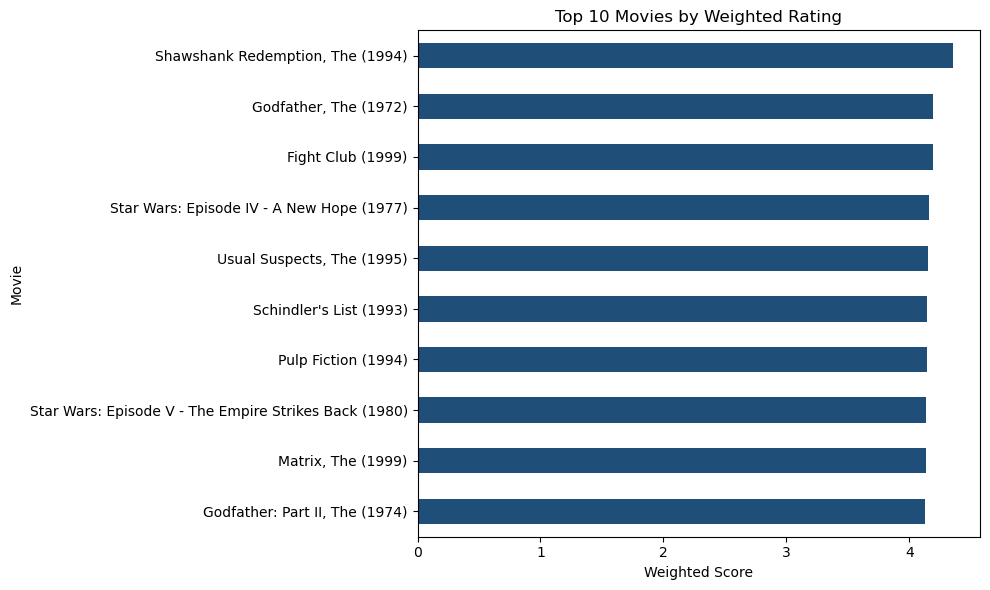

In [19]:
plot_data = weighted_recommendations.sort_values('weighted_score')

ax = plot_data.plot(
    x='title',
    y='weighted_score',
    kind='barh',
    figsize=(10, 6),
    color='#1F4E78',
    legend=False
)

ax.set_title('Top 10 Movies by Weighted Rating')
ax.set_xlabel('Weighted Score')
ax.set_ylabel('Movie')

plt.tight_layout()

plt.savefig(
    IMAGES_DIR / 'top10_recommendations.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## 6. Validate the Recommender

The following checks are used to confirm that the recommendation outputs satisfy the expected conditions, including the number of recommendations, unique movie IDs, minimum rating threshold, valid rating values, and non-missing weighted scores.

In [20]:
assert len(recommendations) <= 10
assert recommendations['movieId'].is_unique
assert recommendations['rating_count'].ge(50).all()
assert recommendations['average_rating'].between(0.5, 5.0).all()
assert recommendations['title'].notna().all()

assert len(weighted_recommendations) <= 10
assert weighted_recommendations['weighted_score'].notna().all()

print('All checks passed.')

All checks passed.


## 7. Parameter Experiment

To examine how the minimum rating threshold affects the recommendations, I will compare the results using thresholds of 20 and 100 ratings. A lower threshold allows more movies to qualify, while a higher threshold requires stronger rating evidence.

In [21]:
print("Top 5 movies with minimum 20 ratings:")
display(
    recommend_popular_movies(
        movie_stats,
        min_ratings=20,
        top_n=5
    )
)

print("Top 5 movies with minimum 100 ratings:")
display(
    recommend_popular_movies(
        movie_stats,
        min_ratings=100,
        top_n=5
    )
)

Top 5 movies with minimum 20 ratings:


,movieId,title,genres,rating_count,average_rating
840,1104,"Streetcar Named Desire, A (1951)",Drama,20,4.475000
277,318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
704,922,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Drama|Film-Noir|Romance,27,4.333333
680,898,"Philadelphia Story, The (1940)",Comedy|Drama|Romance,29,4.310345
905,1204,Lawrence of Arabia (1962),Adventure|Drama|War,45,4.300000


Top 5 movies with minimum 100 ratings:


,movieId,title,genres,rating_count,average_rating
277,318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
659,858,"Godfather, The (1972)",Crime|Drama,192,4.289062
2224,2959,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936
921,1221,"Godfather: Part II, The (1974)",Crime|Drama,129,4.259690
6298,48516,"Departed, The (2006)",Crime|Drama|Thriller,107,4.252336


### Parameter Experiment Findings

- Changing the minimum rating threshold has a clear effect on the recommendation results. With a minimum of 20 ratings, A Streetcar Named Desire (1951) ranks first with an average rating of 4.475, although it has received only 20 ratings. Other movies with relatively small rating counts, such as Sunset Boulevard and The Philadelphia Story, also appear in the Top 5.

- When the threshold is increased to 100 ratings, these movies are excluded because they do not have enough rating evidence. The resulting Top 5 includes movies such as The Shawshank Redemption, The Godfather, Fight Club, The Godfather: Part II, and The Departed, all of which have at least 100 ratings.

- This shows the trade-off involved in choosing a minimum-rating threshold. A lower threshold allows more movies to qualify but can give high rankings to movies based on relatively few ratings.
-  A higher threshold provides stronger rating evidence but may exclude highly rated, less frequently rated movies.

In [22]:
m_80 = movie_stats['rating_count'].quantile(0.80)

qualified_80 = movie_stats[
    movie_stats['rating_count'] >= m_80
]

print(f'80th percentile threshold: {m_80:.1f}')
print(f'Movies qualifying at 80th percentile: {len(qualified_80)}')

print(f'\n90th percentile threshold: {m:.1f}')
print(f'Movies qualifying at 90th percentile: {len(qualified)}')

80th percentile threshold: 12.0
Movies qualifying at 80th percentile: 1967

90th percentile threshold: 27.0
Movies qualifying at 90th percentile: 976


### Percentile Experiment Findings

- Changing the percentile used for the weighted-rating threshold affects the size of the candidate pool. At the 90th percentile, a movie needs at least 27 ratings to qualify, resulting in 976 qualifying movies.

- When the threshold is reduced to the 80th percentile, only 12 ratings are required and the number of qualifying movies increases to 1,967.

- Therefore, lowering the percentile makes the recommender less restrictive and allows more movies with smaller rating counts to be considered. A higher percentile creates a smaller candidate pool with stronger rating evidence, while a lower percentile provides a wider selection but includes movies with less rating evidence.

### Optional Genre-Based Recommendation

As a simple extension, I will filter the popularity recommender by genre. This allows the system to return popular movies belonging to a selected genre while still applying a minimum rating threshold.

In [23]:
def recommend_by_genre(stats, genre, min_ratings=30, top_n=10):
    mask = stats['genres'].str.contains(
        genre,
        case=False,
        na=False
    )

    return recommend_popular_movies(
        stats[mask],
        min_ratings=min_ratings,
        top_n=top_n
    )


comedy_recommendations = recommend_by_genre(
    movie_stats,
    genre='Comedy',
    min_ratings=30,
    top_n=10
)

display(comedy_recommendations)

,movieId,title,genres,rating_count,average_rating
602,750,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,97,4.268041
898,1197,"Princess Bride, The (1987)",Action|Adventure|Comedy|Fantasy|Romance,142,4.232394
257,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,307,4.197068
3617,4973,"Amelie (Fabuleux destin d'Amélie Poulain, Le) ...",Comedy|Romance,120,4.183333
314,356,Forrest Gump (1994),Comedy|Drama|Romance|War,329,4.164134
862,1136,Monty Python and the Holy Grail (1975),Adventure|Comedy|Fantasy,136,4.161765
6659,57669,In Bruges (2008),Comedy|Crime|Drama|Thriller,41,4.158537
2992,4011,Snatch (2000),Comedy|Crime|Thriller,93,4.155914
1729,2324,Life Is Beautiful (La Vita è bella) (1997),Comedy|Drama|Romance|War,88,4.147727
520,608,Fargo (1996),Comedy|Crime|Drama|Thriller,181,4.116022


### Genre Filter Finding

The genre-based extension successfully limits the recommendations to movies containing the selected genre. For the Comedy example, Dr. Strangelove ranks first with an average rating of approximately 4.27 from 97 ratings. This demonstrates how the basic popularity recommender can be adapted to provide recommendations within a specific genre.

## 8. Findings and Limitations

### Notebook Questions

**1. Which movie has the highest rating count, and what is its average rating?**

- Forrest Gump (1994) has the highest rating count with 329 ratings. Its average rating is approximately 4.16.

**2. Which movie ranks first after applying the minimum-rating threshold?**

- Using a minimum threshold of 50 ratings, The Shawshank Redemption (1994) ranks first. It has 317 ratings and an average rating of approximately 4.43.

**3. Which movie ranks first under the weighted-rating method?**

- The Shawshank Redemption (1994) also ranks first under the weighted-rating method, with a weighted score of approximately 4.356.

**4. How many movies qualify under the 90th-percentile threshold?**

- At the 90th percentile, the minimum rating-count threshold is 27 ratings. A total of 976 movies qualify.

**5. What changed when the minimum-rating threshold was increased?**

- Increasing the minimum-rating threshold reduced the number of less frequently rated movies that could appear in the recommendations. At a threshold of 20 ratings, movies such as A Streetcar Named Desire and Sunset Boulevard appeared near the top despite having relatively few ratings. 
- At a threshold of 100 ratings, the recommendations were limited to movies supported by much larger numbers of ratings.

**6. Why is this recommender not personalized?**

- The recommender is not personalized because it produces the same ranked list for every user. It does not use an individual user's previous ratings, preferences, or viewing behaviour when generating recommendations.

**7. What is one example of popularity bias in this system?**

- Popular movies that have already received many ratings are more likely to be recommended. This can give widely rated movies an advantage and make it harder for less-known movies to appear in the recommendation list.

**8. What happens to a new movie with no ratings?**

- A new movie with no ratings cannot satisfy the minimum-rating requirement and does not have enough rating information to calculate a meaningful popularity score. Therefore, it will not appear in the recommendation list. This is an example of the cold-start problem.

### Findings and Limitations

- The MovieLens dataset used in this practical contains 100,836 rating interactions from 610 users. The analysis showed that the data is highly sparse, with approximately 98.30% of possible user-movie interactions having no rating. It also showed that movie rating activity is uneven. Some movies have hundreds of ratings, while many have received only a few.

- Ranking movies using average rating alone was not very reliable. Several movies achieved an average rating of 5.0 but had only one or two ratings. This showed that a high average does not always mean that a movie has strong evidence of being highly rated. Introducing a minimum threshold of 50 ratings improved the ranking by excluding movies with very little rating evidence. Under this method, The Shawshank Redemption ranked first with an average rating of approximately 4.43 from 317 ratings.

- The weighted-rating method provided another way of balancing rating quality and rating quantity. Using the 90th percentile resulted in a threshold of 27 ratings, with 976 movies qualifying. The Shawshank Redemption also ranked first under this method with a weighted score of approximately 4.356. Compared with the minimum-rating approach, the weighted method gave more importance to movies whose high ratings were supported by larger numbers of users.

- However, the recommender has several limitations. First, it is not personalized because every user receives the same recommendations regardless of their individual preferences. Second, it can suffer from popularity bias because movies with many existing ratings have an advantage over less-known movies. Third, it has a cold-start problem because new movies with no ratings cannot appear in the recommendations. The system also does not consider changes in user preferences over time or explain why a user gave a particular rating.

- Future improvements could include collaborative filtering to learn from user-item rating patterns, content-based filtering using movie genres, and hybrid recommendation methods that combine multiple sources of information. Evaluation metrics could also be introduced to compare different recommendation approaches more systematically.